In [1]:
import sys
import os

In [2]:
# Adding the up level folder to path in order to python find the package composed by linear regression implemented
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Local Implementation
from simple_linear_regression import utils
from simple_linear_regression.linear_model import SimpleLinearRegression

# sklearn models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Loading data

In [4]:
df = pd.read_csv("src/scores_sat_gpa.csv")

In [5]:
df.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


# Brief Analysis

In [6]:
df.describe()

,SAT,GPA
count,100.000000,100.000000
mean,1850.760000,3.360500
std,101.566331,0.258845
min,1634.000000,2.400000
25%,1776.500000,3.270000
50%,1850.000000,3.410000
75%,1934.000000,3.520000
max,2050.000000,3.810000


In [7]:
df.isnull().sum()

SAT    0
GPA    0
dtype: int64

In [8]:
df_long = df.melt(var_name="Feature", value_name="Value")

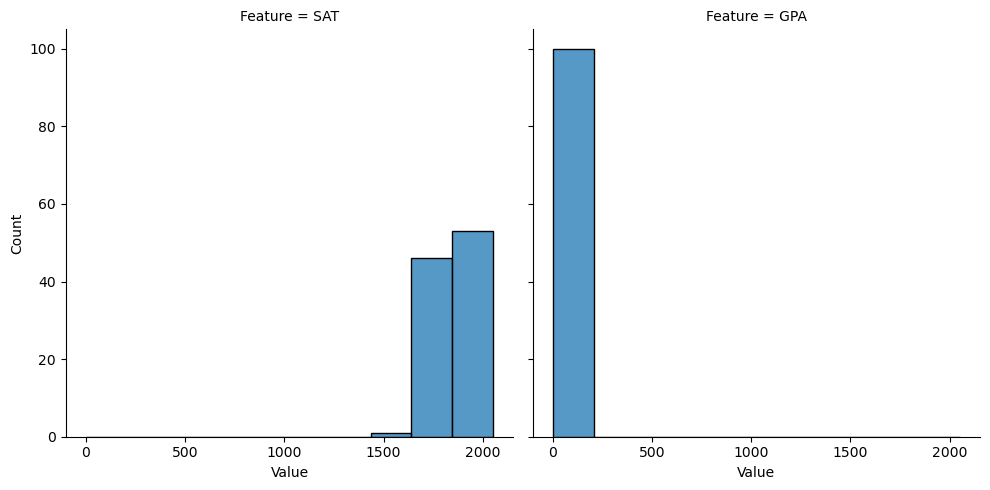

In [13]:
# Histogram for all features
sns.displot(df_long, x="Value", col="Feature", bins=10, kde=False)
plt.show()

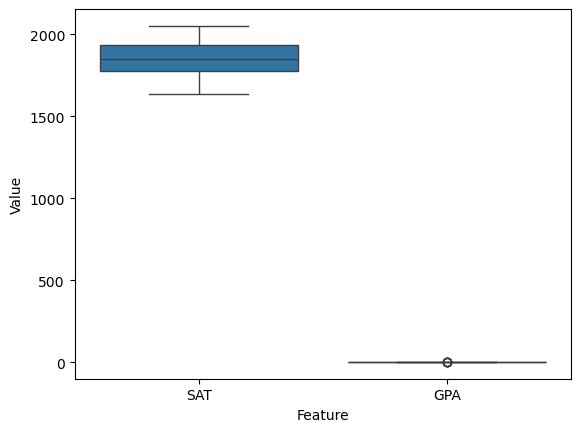

In [14]:
# Boxplot for all features
sns.boxplot(data=df_long, x="Feature", y="Value")
plt.show()

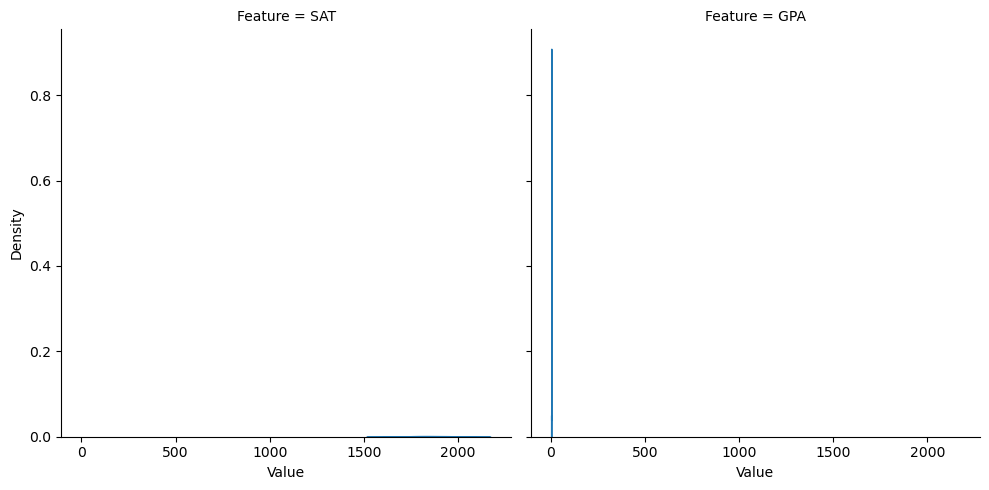

In [15]:
# KDE for all features
sns.displot(df_long, x="Value", col="Feature", kind="kde", fill=True)
plt.show()

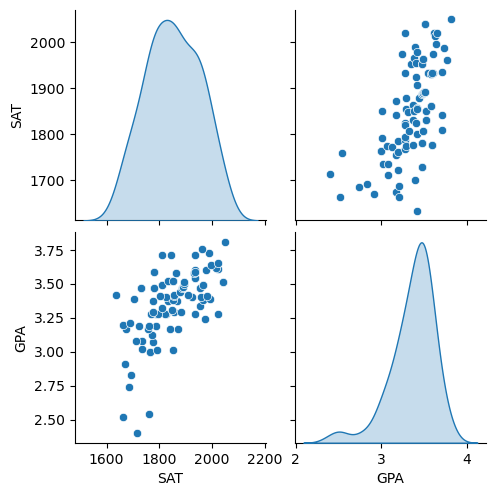

In [16]:
# Pairplot for all features
sns.pairplot(df, diag_kind="kde")
plt.show()

# Split data

In [17]:
seed = 42
train_size = 0.8

In [19]:
X = np.array(df["SAT"])
y = np.array(df["GPA"])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80,), (80,), (20,), (20,))

# Saving Data

In [21]:
utils.save_data(use="train", X=X_train, y=y_train, sufix="scores_sat_gpa")
utils.save_data(use="test", X=X_test, y=y_test, sufix="scores_sat_gpa")

# Normalizing Data

- Its necessary because of the different scale, range of values, is presented for each variable

In [22]:
# Using the internal normalization
X_train_norm_intern = utils.normalization(X_train)
y_train_norm_intern = utils.normalization(y_train)

X_test_norm_intern = utils.normalization(X_test)
y_test_norm_intern = utils.normalization(y_test)

X_train_norm_intern.shape, y_train_norm_intern.shape, X_test_norm_intern.shape, y_test_norm_intern.shape

((80,), (80,), (20,), (20,))

In [23]:
# Using the scikit-learn normalization
scaler = MinMaxScaler()

X_train_norm_skt = scaler.fit_transform(X_train.reshape(-1, 1))
y_train_norm_skt = scaler.fit_transform(y_train.reshape(-1, 1))

X_test_norm_skt = scaler.fit_transform(X_test.reshape(-1, 1))
y_test_norm_skt = scaler.fit_transform(y_test.reshape(-1, 1))

X_train_norm_skt.shape, y_train_norm_skt.shape, X_test_norm_skt.shape, y_test_norm_skt.shape

((80, 1), (80, 1), (20, 1), (20, 1))

# Training model

In [24]:
lr = 0.01           # Learning Rate
tolerance=1e-3
n_iterations = 1e5  # Maximum number of iterations
metric = "mse"      # Metric used - mse: Mean Squared Error
method = "gd"       # Method used - gd: Gradient Descent

In [25]:
intern_model = SimpleLinearRegression(lr=lr, tolerance=tolerance, n_iterations=n_iterations, metric=metric, method=method)

In [26]:
skt_model = LinearRegression()

In [27]:
intern_model.fit(X=X_train_norm_intern, y=y_train_norm_intern)
skt_model.fit(X=X_train_norm_skt, y=y_train_norm_skt)

LinearRegression()

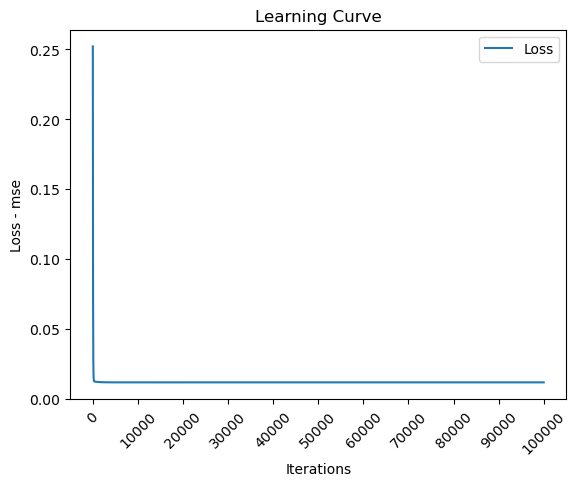

In [28]:
intern_model.learning_curve

In [29]:
intern_model.evaluate(X_train_norm_intern, y_train_norm_intern)

np.float64(0.011947939645053205)

In [30]:
# Predictions
y_pred = skt_model.predict(X_train_norm_skt)
# Evaluation
mse = mean_squared_error(y_train_norm_skt, y_pred)
print(f"MSE: {mse:.3f}")

MSE: 0.024


# Testing Model

In [31]:
intern_model.evaluate(X_test_norm_intern, y_test_norm_intern)

np.float64(0.015424006061666601)

In [32]:
# Predictions
y_pred = skt_model.predict(X_test_norm_skt)
# Evaluation
mse = mean_squared_error(y_test_norm_skt, y_pred)
print(f"MSE: {mse:.3f}")

MSE: 0.031
